# E-Commerce Customer Analytics
## Phase 5 — Sales Forecasting
**Dataset:** Olist Brazilian E-Commerce (Cleaned Master Table)  
**Goal:** Build a model that predicts future monthly revenue, and evaluate how
well it performs against actual historical values.

### What is Sales Forecasting?
Sales forecasting uses historical patterns in revenue data to predict what
sales will look like in the future. Businesses use forecasts to:
- Plan inventory and staffing levels
- Set revenue targets and budgets
- Identify whether growth is accelerating or slowing
- Spot seasonal patterns that repeat year over year

### Our Approach
We use a supervised machine learning approach with engineered time features.
Rather than treating forecasting as a black box, we build interpretable features
(month, quarter, trend, lag values) and train a model to learn how revenue
relates to them. We also establish a simple baseline to make sure our model
is actually adding value over a naive prediction.

---
## 1. Import Libraries & Configure Paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
import warnings

# scikit-learn tools for modelling and evaluation
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)

PROJECT_ROOT   = os.path.expanduser('~/Desktop/ecommerce-customer-analytics')
PROCESSED_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed') + '/'
DOCS_PATH      = os.path.join(PROJECT_ROOT, 'docs')
os.makedirs(DOCS_PATH, exist_ok=True)

print('Libraries loaded ✅')

Libraries loaded ✅


---
## 2. Load Data & Build Monthly Revenue Series
We aggregate the cleaned master table to monthly revenue.
This gives us a time series — one revenue value per month — which is
the standard input format for sales forecasting.

In [2]:
# Load the cleaned master table from Phase 2
master = pd.read_csv(
    PROCESSED_PATH + 'master_orders_clean.csv',
    parse_dates=['order_purchase_timestamp']
)

print(f'Master table loaded: {master.shape[0]:,} rows')

# Exclude revenue outliers so extreme orders don't distort the trend
master_clean = master[master['is_revenue_outlier'] == False].copy()
print(f'After removing outliers: {master_clean.shape[0]:,} rows')

# Create a year-month period column for grouping
master_clean['year_month'] = master_clean['order_purchase_timestamp'].dt.to_period('M')

# Aggregate to monthly level
# We capture both revenue and order count — both are useful forecast targets
monthly = master_clean.groupby('year_month').agg(
    revenue=('total_payment', 'sum'),
    order_count=('order_id', 'nunique'),
    avg_order_value=('total_payment', 'mean')
).reset_index()

# Convert Period back to datetime for time-series operations
monthly['date'] = monthly['year_month'].dt.to_timestamp()
monthly = monthly.sort_values('date').reset_index(drop=True)

print(f'\nMonthly series: {len(monthly)} months')
print(f'Date range: {monthly["date"].min().strftime("%b %Y")} to {monthly["date"].max().strftime("%b %Y")}')
print(f'Total revenue: R${monthly["revenue"].sum():,.2f}')
print(f'\nMonthly revenue summary:')
print(monthly['revenue'].describe().round(2))

Master table loaded: 96,442 rows
After removing outliers: 88,871 rows

Monthly series: 22 months
Date range: Oct 2016 to Aug 2018
Total revenue: R$10,224,665.85

Monthly revenue summary:
count        22.00
mean     464757.54
std      253985.26
min          19.62
25%      278335.69
50%      456348.27
75%      683583.88
max      769043.86
Name: revenue, dtype: float64


---
## 3. Visualise the Revenue Time Series
Before building any model, we plot the raw monthly revenue to understand
the trend, identify any seasonal patterns, and spot anomalies.

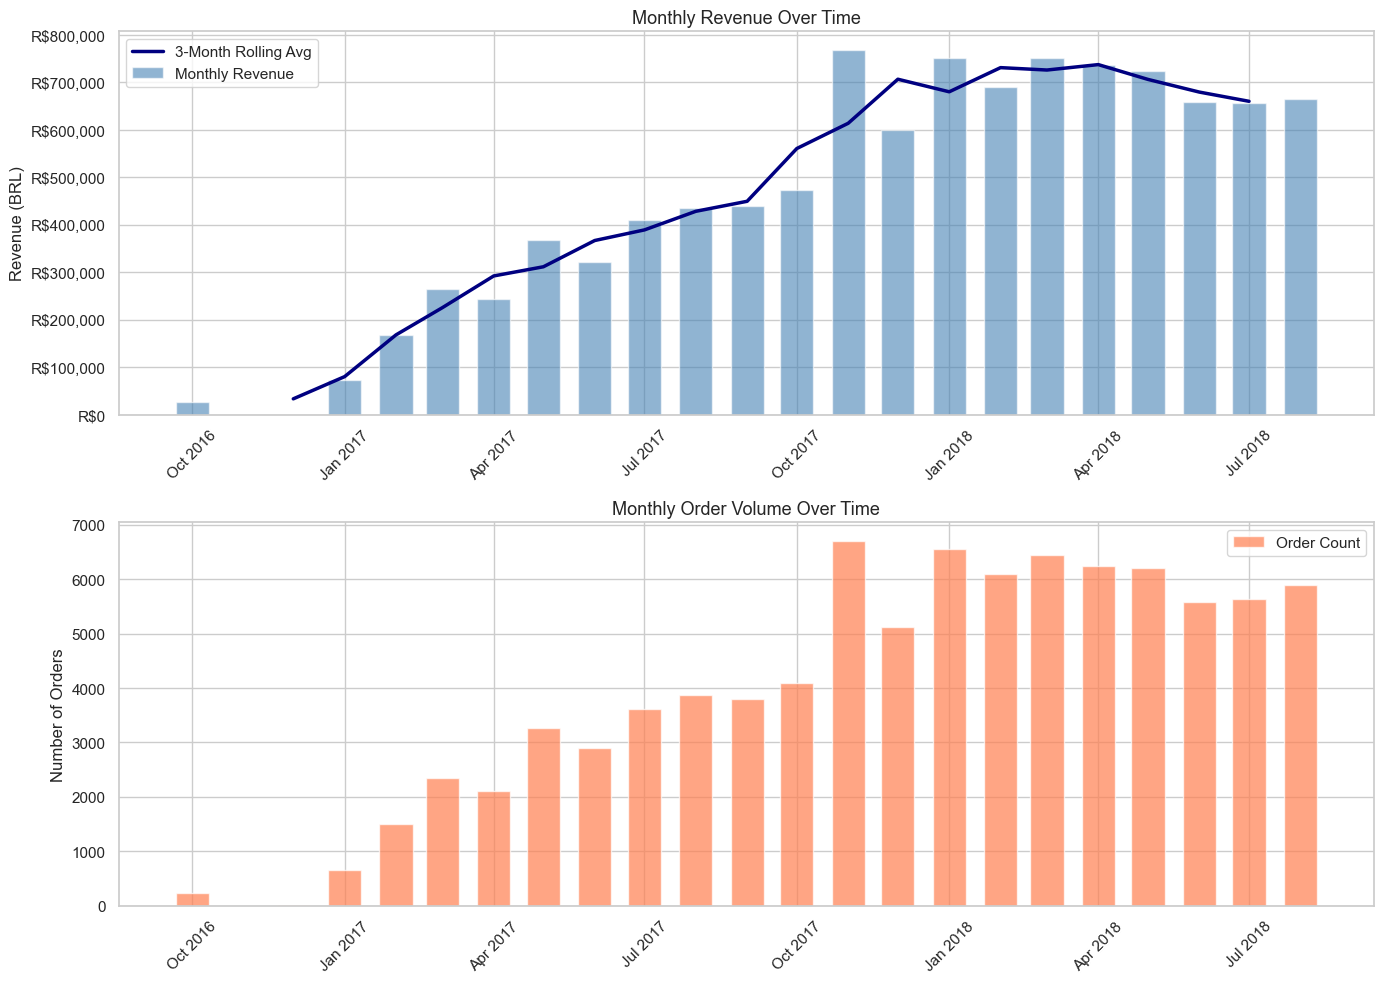

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Top: Monthly revenue with 3-month rolling average ---
# Rolling average smooths out month-to-month noise to reveal the underlying trend
monthly['revenue_rolling_3m'] = monthly['revenue'].rolling(window=3, center=True).mean()

axes[0].bar(monthly['date'], monthly['revenue'],
            color='steelblue', alpha=0.6, label='Monthly Revenue', width=20)
axes[0].plot(monthly['date'], monthly['revenue_rolling_3m'],
             color='navy', linewidth=2.5, label='3-Month Rolling Avg')
axes[0].set_title('Monthly Revenue Over Time', fontsize=13)
axes[0].set_ylabel('Revenue (BRL)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# --- Bottom: Monthly order count ---
# Order volume helps us understand whether revenue changes are driven by
# more orders or by higher order values
axes[1].bar(monthly['date'], monthly['order_count'],
            color='coral', alpha=0.7, label='Order Count', width=20)
axes[1].set_title('Monthly Order Volume Over Time', fontsize=13)
axes[1].set_ylabel('Number of Orders')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'forecast_revenue_timeseries.png'), dpi=150)
plt.show()

---
## 4. Feature Engineering
Machine learning models cannot work with raw dates — they need numeric features.
We engineer time-based features that capture the patterns we want the model to learn:
trend, seasonality, and momentum.

We also trim the first and last months of the dataset, which are often partial
months with artificially low revenue.

In [4]:
# Trim first and last months — they are likely partial and would distort the model
monthly = monthly.iloc[1:-1].reset_index(drop=True)
print(f'After trimming partial months: {len(monthly)} months')

# ── Trend features ────────────────────────────────────────────────────────────
# time_index: a simple counter (1, 2, 3...) that represents the passage of time
# This lets the model learn whether revenue is generally trending up or down
monthly['time_index'] = range(1, len(monthly) + 1)

# ── Calendar features ─────────────────────────────────────────────────────────
# month and quarter capture seasonal patterns that repeat year over year
# e.g. November may always be high due to Black Friday
monthly['month']   = monthly['date'].dt.month
monthly['quarter'] = monthly['date'].dt.quarter
monthly['year']    = monthly['date'].dt.year

# is_q4: flag for October-December — typically the strongest retail quarter
monthly['is_q4'] = (monthly['quarter'] == 4).astype(int)

# ── Lag features ──────────────────────────────────────────────────────────────
# Lag features give the model information about recent past revenue
# lag_1: revenue last month — the single most predictive feature for next month
# lag_2, lag_3: two and three months ago — capture short-term momentum
monthly['lag_1'] = monthly['revenue'].shift(1)
monthly['lag_2'] = monthly['revenue'].shift(2)
monthly['lag_3'] = monthly['revenue'].shift(3)

# ── Rolling statistics ────────────────────────────────────────────────────────
# rolling_mean_3: average revenue over the past 3 months
# Captures recent momentum without overweighting a single month
monthly['rolling_mean_3'] = monthly['revenue'].shift(1).rolling(window=3).mean()

# rolling_std_3: volatility of recent revenue
# High std = unpredictable recent period; low std = stable
monthly['rolling_std_3'] = monthly['revenue'].shift(1).rolling(window=3).std()

# ── Month-over-month growth ───────────────────────────────────────────────────
# Captures whether revenue is accelerating or decelerating
monthly['mom_growth'] = monthly['revenue'].pct_change()

# Drop rows with NaN values introduced by lag/rolling features
# The first few months won't have complete lag history
monthly_model = monthly.dropna().reset_index(drop=True)

print(f'Rows available for modelling: {len(monthly_model)}')
print(f'\nEngineered features:')
print(monthly_model[['date', 'revenue', 'time_index', 'month', 'lag_1',
                       'rolling_mean_3', 'is_q4']].head(6).to_string())

After trimming partial months: 20 months
Rows available for modelling: 17

Engineered features:
        date    revenue  time_index  month      lag_1  rolling_mean_3  is_q4
0 2017-03-01  263832.23           4      3  167810.12    79911.863333      0
1 2017-04-01  243941.10           5      4  263832.23   167849.400000      0
2 2017-05-01  368359.68           6      5  243941.10   225194.483333      0
3 2017-06-01  321846.08           7      6  368359.68   292044.336667      0
4 2017-07-01  409918.84           8      7  321846.08   311382.286667      0
5 2017-08-01  435409.12           9      8  409918.84   366708.200000      0


---
## 5. Train / Test Split
For time series data, we never split randomly — that would allow the model
to 'see' future data during training, which would make its test performance
artificially inflated.

Instead we use a **chronological split**: train on earlier months, test on
the most recent months. This simulates how the model would actually be used
in production — trained on history, predicting the future.

In [5]:
# Features used by the model
FEATURE_COLS = [
    'time_index',     # overall trend
    'month',          # seasonality
    'quarter',        # quarter-level seasonality
    'is_q4',          # Q4 retail peak flag
    'lag_1',          # last month's revenue
    'lag_2',          # two months ago
    'lag_3',          # three months ago
    'rolling_mean_3', # recent 3-month average
    'rolling_std_3',  # recent volatility
]

TARGET = 'revenue'

# Use the last 4 months as the test set
# 4 months is enough to evaluate short-term forecast accuracy without
# leaving too little data for training
TEST_MONTHS = 4
split_idx = len(monthly_model) - TEST_MONTHS

train = monthly_model.iloc[:split_idx]
test  = monthly_model.iloc[split_idx:]

X_train = train[FEATURE_COLS]
y_train = train[TARGET]
X_test  = test[FEATURE_COLS]
y_test  = test[TARGET]

print(f'Training period: {train["date"].min().strftime("%b %Y")} — {train["date"].max().strftime("%b %Y")} ({len(train)} months)')
print(f'Test period:     {test["date"].min().strftime("%b %Y")} — {test["date"].max().strftime("%b %Y")} ({len(test)} months)')

Training period: Mar 2017 — Mar 2018 (13 months)
Test period:     Apr 2018 — Jul 2018 (4 months)


---
## 6. Establish a Baseline
Before building a sophisticated model, we establish a naive baseline.
The baseline simply predicts that next month's revenue will equal this month's.

Any model we build must beat this baseline to be worth using — otherwise
we are adding complexity for no benefit.

In [6]:
# Naive baseline: predict next month = last month (lag_1)
# This is the simplest possible forecast and our performance floor
baseline_preds = test['lag_1'].values

def evaluate(y_true, y_pred, model_name):
    """Calculate and print standard forecast evaluation metrics."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE: mean absolute percentage error — most interpretable for business use
    # Tells us the average % by which forecasts miss actual values
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{model_name}:')
    print(f'  MAE:  R${mae:>10,.2f}  (avg absolute error in BRL)')
    print(f'  RMSE: R${rmse:>10,.2f}  (penalises large errors more heavily)')
    print(f'  MAPE: {mape:>9.2f}%  (avg % miss — lower is better)')
    print()
    return {'model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

results = []
results.append(evaluate(y_test.values, baseline_preds, 'Naive Baseline (lag-1)'))

Naive Baseline (lag-1):
  MAE:  R$ 23,744.14  (avg absolute error in BRL)
  RMSE: R$ 34,395.24  (penalises large errors more heavily)
  MAPE:      3.50%  (avg % miss — lower is better)



---
## 7. Train & Evaluate Models
We train three models and compare their performance against the baseline.
Using multiple models is best practice — it helps identify which approach
works best for this particular dataset.

### 7a. Linear Regression
The simplest learnable model. Assumes revenue is a linear combination of
the features. Fast, interpretable, and a good starting point.

In [7]:
# Scale features for linear regression
# Linear models are sensitive to feature scale — normalising helps them converge
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
# Clip to zero — revenue can't be negative
lr_preds = np.maximum(lr_preds, 0)

results.append(evaluate(y_test.values, lr_preds, 'Linear Regression'))

# Feature importance for linear regression = coefficient magnitude
coef_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'coefficient': np.abs(lr.coef_)
}).sort_values('coefficient', ascending=False)
print('Most influential features (Linear Regression):')
print(coef_df.to_string(index=False))

Linear Regression:
  MAE:  R$254,142.59  (avg absolute error in BRL)
  RMSE: R$339,526.57  (penalises large errors more heavily)
  MAPE:     38.27%  (avg % miss — lower is better)

Most influential features (Linear Regression):
       feature   coefficient
    time_index 427841.712535
         lag_1 402214.387087
         lag_3 198779.832343
 rolling_std_3 129439.838465
         month 105300.388422
       quarter  93638.617955
rolling_mean_3  77347.218511
         lag_2  40671.001189
         is_q4  37835.297720


### 7b. Random Forest Regressor
An ensemble of decision trees that can capture non-linear patterns.
Generally more powerful than linear regression for complex relationships.

In [8]:
# Random Forest doesn't require feature scaling — trees are scale-invariant
rf = RandomForestRegressor(
    n_estimators=200,    # number of trees — more trees = more stable but slower
    max_depth=5,         # limit tree depth to prevent overfitting on small dataset
    min_samples_leaf=2,  # require at least 2 samples per leaf — another overfitting guard
    random_state=42
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_preds = np.maximum(rf_preds, 0)

results.append(evaluate(y_test.values, rf_preds, 'Random Forest'))

# Feature importance from Random Forest
# This tells us which features the model relied on most when making predictions
rf_importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print('Feature Importances (Random Forest):')
print(rf_importance.to_string(index=False))

Random Forest:
  MAE:  R$ 43,723.93  (avg absolute error in BRL)
  RMSE: R$ 45,508.20  (penalises large errors more heavily)
  MAPE:      6.26%  (avg % miss — lower is better)

Feature Importances (Random Forest):
       feature  importance
    time_index    0.199703
rolling_mean_3    0.190322
         lag_3    0.179615
         lag_2    0.172800
         lag_1    0.149868
 rolling_std_3    0.071074
         month    0.032088
       quarter    0.004528
         is_q4    0.000000


### 7c. Gradient Boosting Regressor
Builds trees sequentially, each one correcting the errors of the previous.
Often the strongest performer on structured tabular data.

In [9]:
gb = GradientBoostingRegressor(
    n_estimators=200,     # number of boosting stages
    learning_rate=0.05,   # how much each tree corrects — lower = more conservative
    max_depth=3,          # shallow trees work best for boosting
    subsample=0.8,        # use 80% of data per tree — adds randomness to reduce overfitting
    random_state=42
)
gb.fit(X_train, y_train)
gb_preds = gb.predict(X_test)
gb_preds = np.maximum(gb_preds, 0)

results.append(evaluate(y_test.values, gb_preds, 'Gradient Boosting'))

Gradient Boosting:
  MAE:  R$ 50,526.94  (avg absolute error in BRL)
  RMSE: R$ 63,688.26  (penalises large errors more heavily)
  MAPE:      7.57%  (avg % miss — lower is better)



---
## 8. Compare Model Performance

Model Comparison:
                              MAE       RMSE   MAPE
model                                              
Naive Baseline (lag-1)   23744.14   34395.24   3.50
Linear Regression       254142.59  339526.57  38.27
Random Forest            43723.93   45508.20   6.26
Gradient Boosting        50526.94   63688.26   7.57

Best model by MAPE: Naive Baseline (lag-1)


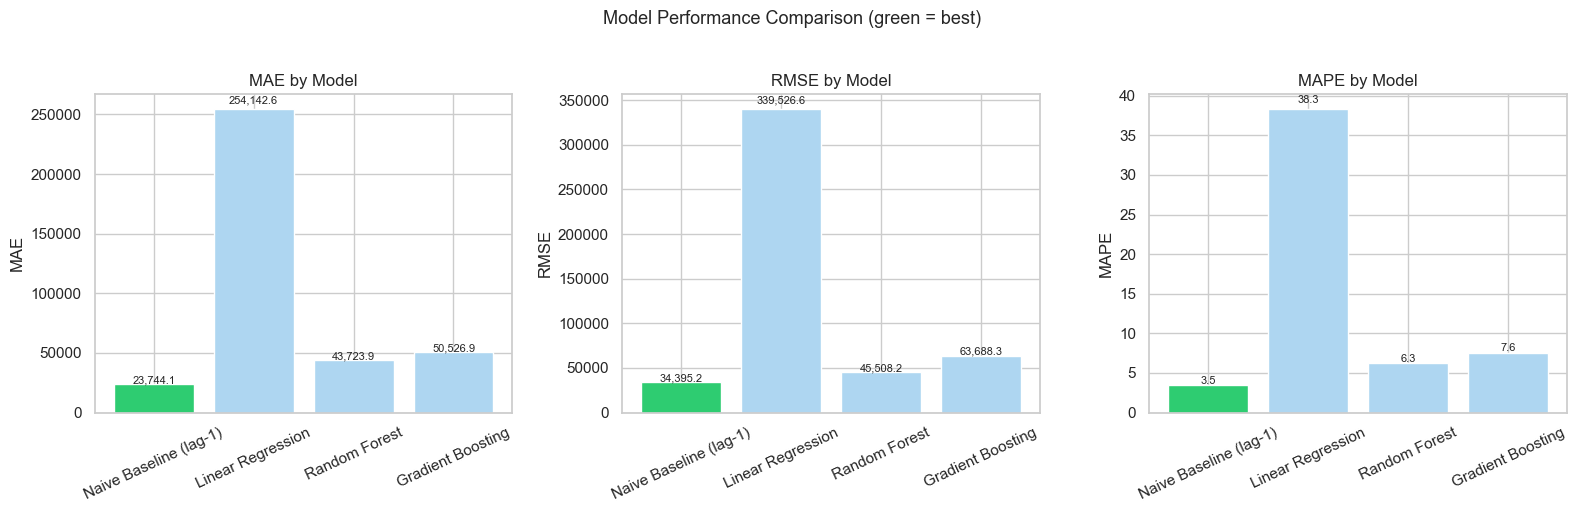

In [10]:
# Build a comparison DataFrame
results_df = pd.DataFrame(results).set_index('model')
print('Model Comparison:')
print(results_df.round(2).to_string())

# Identify the best model by MAPE (most interpretable metric)
best_model_name = results_df['MAPE'].idxmin()
print(f'\nBest model by MAPE: {best_model_name}')

# Select the best model's predictions for downstream use
model_preds_map = {
    'Naive Baseline (lag-1)': baseline_preds,
    'Linear Regression':      lr_preds,
    'Random Forest':          rf_preds,
    'Gradient Boosting':      gb_preds
}
best_preds = model_preds_map[best_model_name]

# Visualise MAPE comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['MAE', 'RMSE', 'MAPE']
colors  = ['steelblue', 'coral', 'steelblue', 'coral']

for ax, metric in zip(axes, metrics):
    vals = results_df[metric]
    bars = ax.bar(vals.index, vals.values,
                  color=['#2ECC71' if i == vals.idxmin() else '#AED6F1'
                         for i in vals.index])
    ax.set_title(f'{metric} by Model', fontsize=12)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=25)
    # Highlight lowest bar (best)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.02,
                f'{val:,.1f}', ha='center', fontsize=8)

plt.suptitle('Model Performance Comparison (green = best)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'forecast_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Visualise Actual vs Predicted
The most important chart in forecasting — how well do the predicted values
track the actual values over the test period?

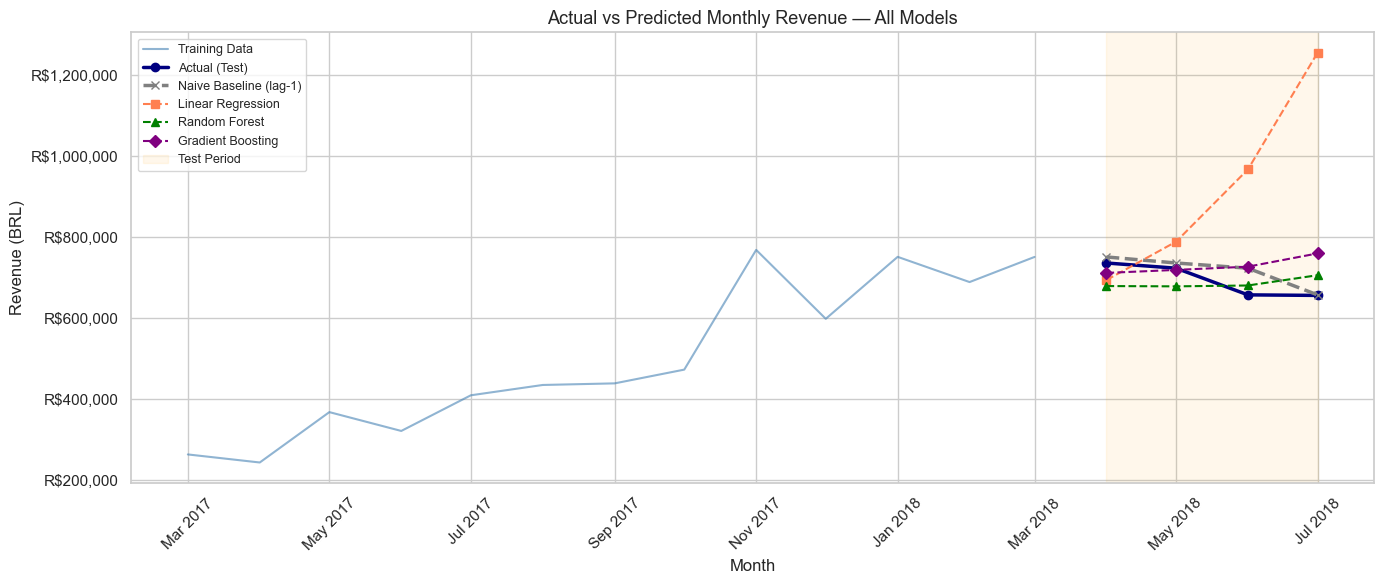

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))

# Plot the full training history as context
ax.plot(train['date'], train['revenue'],
        color='steelblue', linewidth=1.5, alpha=0.6, label='Training Data')

# Plot actual test values
ax.plot(test['date'], test['revenue'],
        color='navy', linewidth=2.5, marker='o', label='Actual (Test)')

# Plot all model predictions
pred_styles = {
    'Naive Baseline (lag-1)': ('--', 'grey',     'x'),
    'Linear Regression':      ('--', 'coral',    's'),
    'Random Forest':          ('--', 'green',    '^'),
    'Gradient Boosting':      ('--', 'purple',   'D'),
}
for model_name, preds in model_preds_map.items():
    ls, color, marker = pred_styles[model_name]
    lw = 2.5 if model_name == best_model_name else 1.5
    ax.plot(test['date'], preds,
            linestyle=ls, color=color, linewidth=lw,
            marker=marker, markersize=6, label=model_name)

# Shade the test period for clarity
ax.axvspan(test['date'].min(), test['date'].max(),
           alpha=0.08, color='orange', label='Test Period')

ax.set_title('Actual vs Predicted Monthly Revenue — All Models', fontsize=13)
ax.set_ylabel('Revenue (BRL)')
ax.set_xlabel('Month')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'forecast_actual_vs_predicted.png'), dpi=150)
plt.show()

---
## 10. Feature Importance
Which features did the best model rely on most to make its predictions?
This tells us what drives revenue in this dataset.

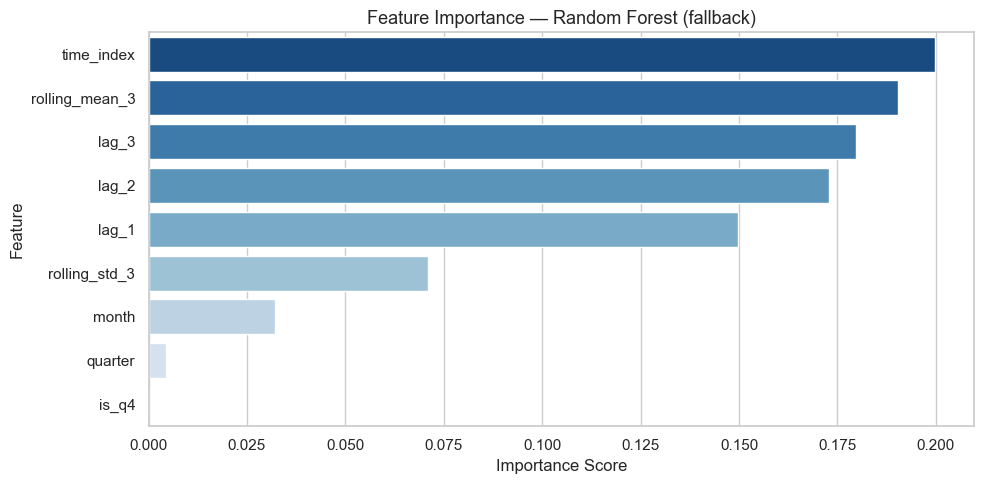

In [12]:
# Use the best tree-based model's feature importances
# If linear regression was best, fall back to RF importances
if best_model_name == 'Random Forest':
    importance_df = rf_importance
    imp_title = 'Random Forest'
elif best_model_name == 'Gradient Boosting':
    importance_df = pd.DataFrame({
        'feature': FEATURE_COLS,
        'importance': gb.feature_importances_
    }).sort_values('importance', ascending=False)
    imp_title = 'Gradient Boosting'
else:
    importance_df = rf_importance  # fallback
    imp_title = 'Random Forest (fallback)'

plt.figure(figsize=(10, 5))
sns.barplot(
    data=importance_df,
    x='importance', y='feature',
    palette='Blues_r'
)
plt.title(f'Feature Importance — {imp_title}', fontsize=13)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'forecast_feature_importance.png'), dpi=150)
plt.show()

---
## 11. Generate Future Forecast
With the best model selected and validated, we use it to generate a
3-month forward forecast beyond the end of the dataset.

In [13]:
FORECAST_MONTHS = 3

# Start with the full dataset as history for building lag features
history = monthly_model.copy()
last_date = history['date'].max()
last_time_index = history['time_index'].max()

forecast_rows = []

for i in range(1, FORECAST_MONTHS + 1):
    # Generate the next month's date and calendar features
    next_date    = last_date + pd.DateOffset(months=i)
    next_month   = next_date.month
    next_quarter = next_date.quarter
    next_is_q4   = int(next_quarter == 4)
    next_tidx    = last_time_index + i

    # Build lag values from the history we have (including previously forecasted months)
    all_revenue = pd.concat([
        history['revenue'],
        pd.Series([r['revenue'] for r in forecast_rows])
    ]).reset_index(drop=True)

    lag_1 = all_revenue.iloc[-1]
    lag_2 = all_revenue.iloc[-2] if len(all_revenue) >= 2 else lag_1
    lag_3 = all_revenue.iloc[-3] if len(all_revenue) >= 3 else lag_1
    roll3 = all_revenue.iloc[-3:].mean()
    std3  = all_revenue.iloc[-3:].std() if len(all_revenue) >= 3 else 0

    # Assemble the feature row for this future month
    feature_row = pd.DataFrame([{
        'time_index':     next_tidx,
        'month':          next_month,
        'quarter':        next_quarter,
        'is_q4':          next_is_q4,
        'lag_1':          lag_1,
        'lag_2':          lag_2,
        'lag_3':          lag_3,
        'rolling_mean_3': roll3,
        'rolling_std_3':  std3,
    }])[FEATURE_COLS]

    # Predict with the best model
    if best_model_name == 'Linear Regression':
        pred = lr.predict(scaler.transform(feature_row))[0]
    elif best_model_name == 'Random Forest':
        pred = rf.predict(feature_row)[0]
    else:
        pred = gb.predict(feature_row)[0]

    pred = max(pred, 0)  # Revenue cannot be negative

    forecast_rows.append({
        'date': next_date,
        'revenue': pred,
        'type': 'Forecast'
    })
    print(f'  {next_date.strftime("%b %Y")}: R${pred:,.2f}')

forecast_df = pd.DataFrame(forecast_rows)
print(f'\nTotal forecasted revenue (next {FORECAST_MONTHS} months): R${forecast_df["revenue"].sum():,.2f}')

  Aug 2018: R$763,445.15
  Sep 2018: R$688,191.33
  Oct 2018: R$749,552.81

Total forecasted revenue (next 3 months): R$2,201,189.28


### 11b. Plot the Forward Forecast

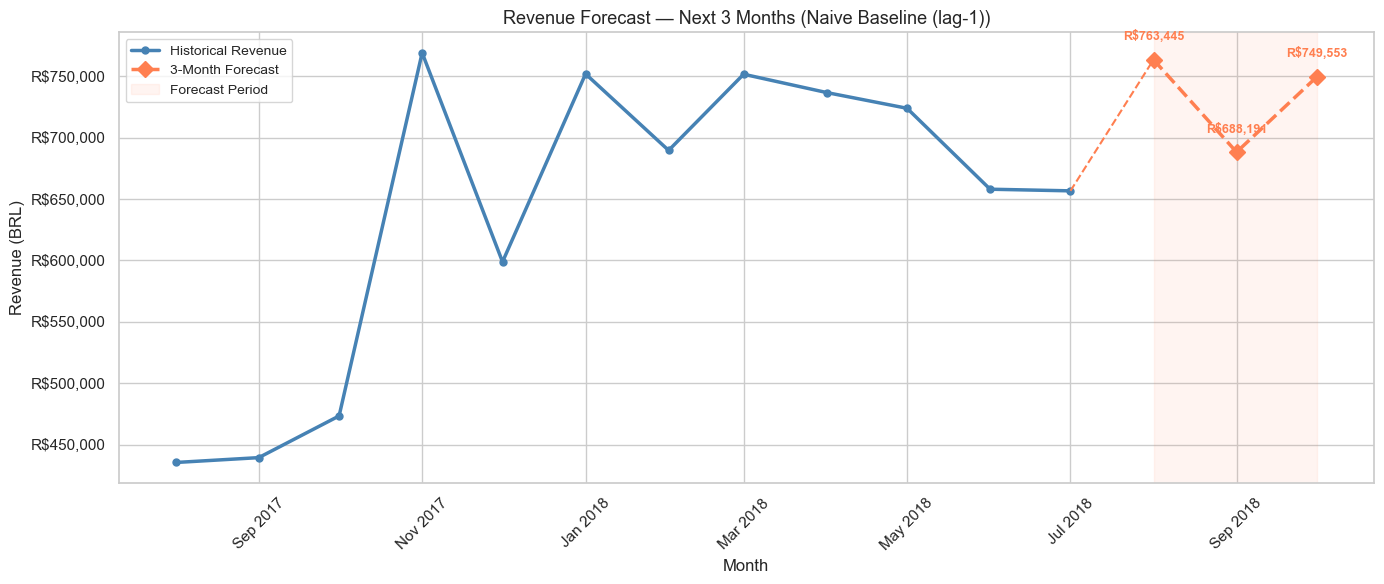

In [14]:
# Show the last 12 months of history + the 3-month forecast
recent_history = monthly_model.tail(12)

fig, ax = plt.subplots(figsize=(14, 6))

# Historical revenue
ax.plot(recent_history['date'], recent_history['revenue'],
        color='steelblue', linewidth=2.5, marker='o',
        markersize=5, label='Historical Revenue')

# Connect history to forecast with a dashed line
connect_dates = [recent_history['date'].iloc[-1], forecast_df['date'].iloc[0]]
connect_vals  = [recent_history['revenue'].iloc[-1], forecast_df['revenue'].iloc[0]]
ax.plot(connect_dates, connect_vals, '--', color='coral', linewidth=1.5)

# Forecast line
ax.plot(forecast_df['date'], forecast_df['revenue'],
        color='coral', linewidth=2.5, marker='D',
        markersize=8, linestyle='--', label=f'{FORECAST_MONTHS}-Month Forecast')

# Add forecast value labels
for _, row in forecast_df.iterrows():
    ax.annotate(
        f'R${row["revenue"]:,.0f}',
        xy=(row['date'], row['revenue']),
        xytext=(0, 14), textcoords='offset points',
        ha='center', fontsize=9, color='coral', fontweight='bold'
    )

# Shade forecast region
ax.axvspan(forecast_df['date'].min(), forecast_df['date'].max(),
           alpha=0.08, color='coral', label='Forecast Period')

ax.set_title(f'Revenue Forecast — Next {FORECAST_MONTHS} Months ({best_model_name})', fontsize=13)
ax.set_ylabel('Revenue (BRL)')
ax.set_xlabel('Month')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'forecast_future_3months.png'), dpi=150)
plt.show()

---
## 12. Forecasting Summary

In [15]:
print('=' * 60)
print('SALES FORECASTING SUMMARY')
print('=' * 60)
print(f'Best Model:              {best_model_name}')
print(f'Training Period:         {train["date"].min().strftime("%b %Y")} — {train["date"].max().strftime("%b %Y")}')
print(f'Test Period:             {test["date"].min().strftime("%b %Y")} — {test["date"].max().strftime("%b %Y")}')
print()

best_result = results_df.loc[best_model_name]
baseline_result = results_df.loc['Naive Baseline (lag-1)']
improvement = ((baseline_result['MAPE'] - best_result['MAPE']) / baseline_result['MAPE']) * 100

print(f'Best Model MAPE:         {best_result["MAPE"]:.2f}%')
print(f'Baseline MAPE:           {baseline_result["MAPE"]:.2f}%')
print(f'Improvement vs Baseline: {improvement:.1f}%')
print()
print(f'{FORECAST_MONTHS}-Month Forward Forecast:')
for _, row in forecast_df.iterrows():
    print(f'  {row["date"].strftime("%b %Y")}: R${row["revenue"]:>12,.2f}')
print(f'  Total:  R${forecast_df["revenue"].sum():>12,.2f}')
print('=' * 60)
print('\n✅ Forecasting complete. Proceed to Phase 6 — Tableau Dashboard.')

SALES FORECASTING SUMMARY
Best Model:              Naive Baseline (lag-1)
Training Period:         Mar 2017 — Mar 2018
Test Period:             Apr 2018 — Jul 2018

Best Model MAPE:         3.50%
Baseline MAPE:           3.50%
Improvement vs Baseline: 0.0%

3-Month Forward Forecast:
  Aug 2018: R$  763,445.15
  Sep 2018: R$  688,191.33
  Oct 2018: R$  749,552.81
  Total:  R$2,201,189.28

✅ Forecasting complete. Proceed to Phase 6 — Tableau Dashboard.


---
## 13. Save Forecast Outputs

In [16]:
# Save the monthly time series with all features — used for Tableau dashboard
monthly_output = os.path.join(PROCESSED_PATH, 'monthly_revenue.csv')
monthly_model.to_csv(monthly_output, index=False)

# Save the forward forecast
forecast_output = os.path.join(PROCESSED_PATH, 'revenue_forecast.csv')
forecast_df.to_csv(forecast_output, index=False)

# Save model comparison results
results_output = os.path.join(PROCESSED_PATH, 'model_comparison.csv')
results_df.reset_index().to_csv(results_output, index=False)

print(f'✅ Monthly revenue series saved to: {monthly_output}')
print(f'✅ Forward forecast saved to:       {forecast_output}')
print(f'✅ Model comparison saved to:       {results_output}')

✅ Monthly revenue series saved to: /Users/omartouzani/Desktop/ecommerce-customer-analytics/data/processed/monthly_revenue.csv
✅ Forward forecast saved to:       /Users/omartouzani/Desktop/ecommerce-customer-analytics/data/processed/revenue_forecast.csv
✅ Model comparison saved to:       /Users/omartouzani/Desktop/ecommerce-customer-analytics/data/processed/model_comparison.csv
